The SAN notation in chess only records the piece that moved, not which piece is delivering the check.
Missed the case called as discovered check, and it can happen with any moving piece, including the king.

In [2]:
import pandas as pd

In [24]:
import matplotlib.pyplot as plt

In [12]:
df_games = pd.read_csv("../data/processed/games.csv")

df_moves = pd.read_csv("../data/processed/moves.csv")


In [14]:
df_games.head()

,game_id,date,color,opponent,your_rating,opponent_rating,rating_diff,result,opening,eco,termination,time_control
0,jXLQFuFS,2026.06.30,Black,TootMaGoot,1153,1111,5.0,Win,Queen's Pawn Game: Zukertort Variation,D02,Time forfeit,180+2
1,q4BZb2gs,2026.06.30,Black,creutyion,1159,1158,-6.0,Loss,Sicilian Defense: Katalimov Variation,B27,Time forfeit,180+2
2,qBg8Gq00,2026.06.30,Black,E3xec,1153,1141,6.0,Win,Sicilian Defense: Bowdler Attack,B20,Normal,180+2
3,MRJRjPXd,2026.06.30,White,BULschachfreund,1152,1241,1.0,Draw,Queen's Pawn Game: Accelerated London System,D00,Normal,180+2
4,ma9DfXH6,2026.06.30,Black,BULschachfreund,1144,1249,8.0,Win,Queen's Pawn Game,D00,Normal,180+2


In [66]:
df_moves.head()

,game_id,move_number,ply,color,fen_before,san,uci,clock,opening,time_control,result,your_rating,opponent_rating,piece,is_capture,is_check,is_castling,is_promotion,is_en_passant,piece_type
0,jXLQFuFS,1,2,Black,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,d5,d7d5,180,Queen's Pawn Game: Zukertort Variation,180+2,Win,1153,1111,Pawn,False,False,False,False,False,1
1,jXLQFuFS,2,4,Black,rnbqkbnr/ppp1pppp/8/3p4/3P4/5N2/PPP1PPPP/RNBQK...,Bf5,c8f5,179,Queen's Pawn Game: Zukertort Variation,180+2,Win,1153,1111,Bishop,False,False,False,False,False,3
2,jXLQFuFS,3,6,Black,rn1qkbnr/ppp1pppp/8/3p1b2/3P4/2N2N2/PPP1PPPP/R...,e6,e7e6,180,Queen's Pawn Game: Zukertort Variation,180+2,Win,1153,1111,Pawn,False,False,False,False,False,1
3,jXLQFuFS,4,8,Black,rn1qkbnr/ppp2ppp/4p3/3p1b2/3P3N/2N5/PPP1PPPP/R...,Qxh4,d8h4,180,Queen's Pawn Game: Zukertort Variation,180+2,Win,1153,1111,Queen,True,False,False,False,False,5
4,q4BZb2gs,1,2,Black,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,c5,c7c5,180,Sicilian Defense: Katalimov Variation,180+2,Loss,1159,1158,Pawn,False,False,False,False,False,1


In [21]:
print("Total no. of games", len(df_games))
print("Total games as white:", (df_games["color"] == "White").sum())
print("Total games as Black:", (df_games["color"] == "Black").sum())

Total no. of games 304
Total games as white: 150
Total games as Black: 154


In [22]:
summary = pd.crosstab(df_games["color"], df_games["result"])
print(summary)

result  Draw  Loss  Win
color                  
Black      7    57   90
White      8    76   66


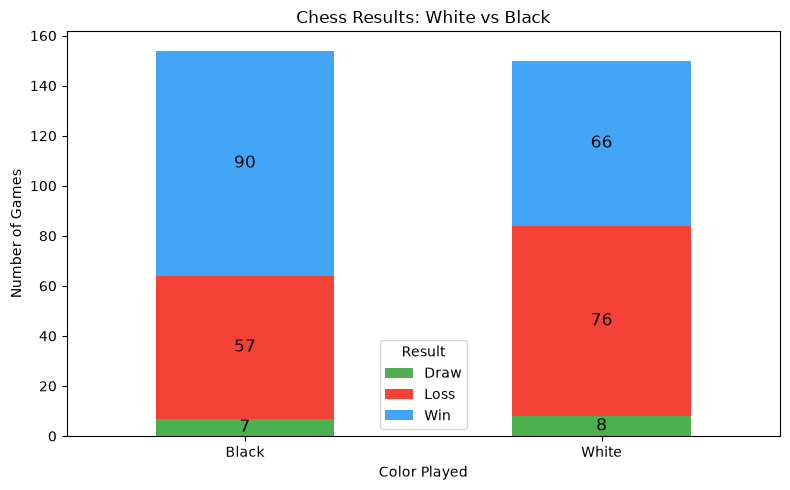

In [54]:
colors = ["#4CAF50", "#F44336", "#42A5F5"]  # Green, Red, Blue

ax = summary.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=colors
)

for container in ax.containers:
    ax.bar_label(container, label_type="center", color="black", fontsize=12)

plt.title("Chess Results: White vs Black")
plt.xlabel("Color Played")
plt.ylabel("Number of Games")
plt.xticks(rotation=0)
plt.legend(title="Result")
plt.tight_layout()
plt.show()

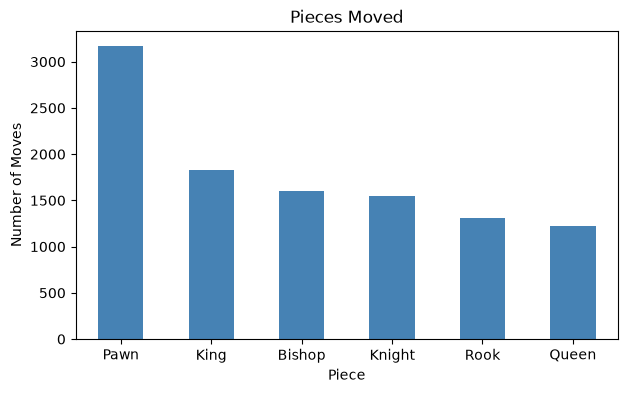

In [37]:
piece_counts = df_moves["piece"].value_counts()

piece_counts.plot(
    kind="bar",
    color="steelblue",
    figsize=(7,4)
)

plt.title("Pieces Moved")
plt.xlabel("Piece")
plt.ylabel("Number of Moves")
plt.xticks(rotation=0)
plt.show()

<Axes: title={'center': 'Captures by piece'}, xlabel='piece'>

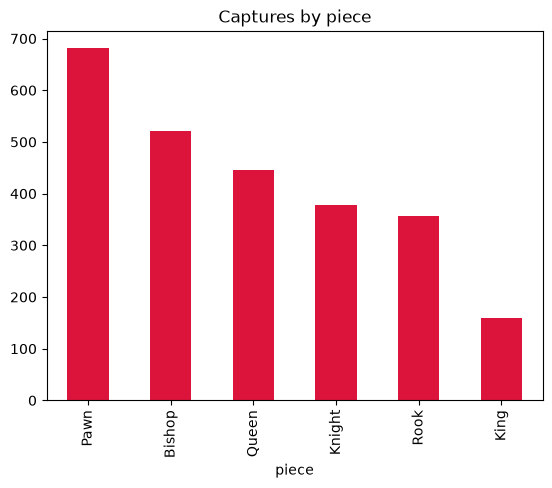

In [ ]:
captures = (
    df_moves[df_moves["is_capture"]]
    .groupby("piece")
    .size()
    .sort_values(ascending=False)
)

captures.plot(kind="bar", color="crimson", title="Captures by piece")
# Which pieces are making the captures?

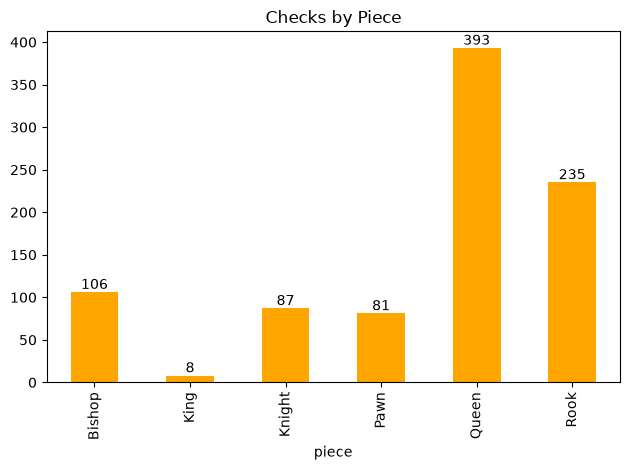

In [ ]:
checks = (
    df_moves[df_moves["is_check"]]
    .groupby("piece")
    .size()
)

checks.plot(kind="bar", color="orange",title="Checks by piece")
# "Which of my moves resulted in check?"
# not
# "Which piece delivered the check?"

In [53]:
df_moves[
    (df_moves["piece"] == "King") &
    (df_moves["is_check"])
]

,game_id,move_number,ply,color,fen_before,san,uci,clock,opening,time_control,result,your_rating,opponent_rating,piece,is_capture,is_check,is_castling,is_promotion,is_en_passant,piece_type
685,DF7RHDrS,35,69,White,6r1/p3n3/1p1qp3/3p4/1n1P1P2/P2QP1P1/1k3K1R/8 w...,Kf3+,f2f3,36,Queen's Pawn Game: Accelerated London System,180+2,Win,1147,1252,King,False,True,False,False,False,6
2177,VGlQ0fcG,67,134,Black,6K1/8/6k1/8/8/8/5p2/2brr1qr b - - 1 67,Kf5+,g6f5,81,Sicilian Defense: Katalimov Variation,180+2,Win,1149,1109,King,False,True,False,False,False,6
2179,VGlQ0fcG,69,138,Black,4K3/8/8/8/4k3/8/5p2/2brr1qr b - - 5 69,Kf3+,e4f3,81,Sicilian Defense: Katalimov Variation,180+2,Win,1149,1109,King,False,True,False,False,False,6
2181,VGlQ0fcG,71,142,Black,6K1/8/8/8/8/6k1/5p2/2brr1qr b - - 9 71,Kh3+,g3h3,81,Sicilian Defense: Katalimov Variation,180+2,Win,1149,1109,King,False,True,False,False,False,6
2182,VGlQ0fcG,72,144,Black,7K/8/8/8/8/7k/5p2/2brr1qr b - - 11 72,Kg2+,h3g2,82,Sicilian Defense: Katalimov Variation,180+2,Win,1149,1109,King,False,True,False,False,False,6
2183,VGlQ0fcG,73,146,Black,6K1/8/8/8/8/8/5pk1/2brr1qr b - - 13 73,Kf1+,g2f1,83,Sicilian Defense: Katalimov Variation,180+2,Win,1149,1109,King,False,True,False,False,False,6
2185,VGlQ0fcG,75,150,Black,4K3/8/8/8/8/8/4kp2/2brr1qr b - - 17 75,Kd2+,e2d2,85,Sicilian Defense: Katalimov Variation,180+2,Win,1149,1109,King,False,True,False,False,False,6
2186,VGlQ0fcG,76,152,Black,3K4/8/8/8/8/8/3k1p2/2brr1qr b - - 19 76,Kc2+,d2c2,85,Sicilian Defense: Katalimov Variation,180+2,Win,1149,1109,King,False,True,False,False,False,6


In [ ]:
df_moves[(df_moves["piece"] == "king") & (df_moves["is_check"] == True)]

,game_id,move_number,ply,color,fen_before,san,uci,clock,opening,time_control,result,your_rating,opponent_rating,piece,is_capture,is_check,is_castling,is_promotion,is_en_passant,piece_type


<Axes: title={'center': 'Average game length by result'}, xlabel='result'>

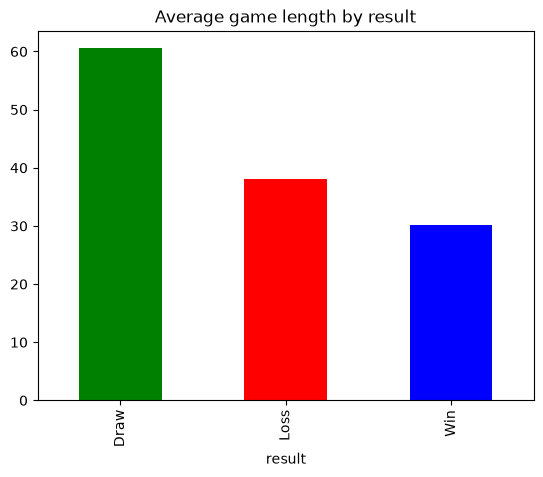

In [45]:
game_lengths = (
    df_moves.groupby("game_id")
    .size()
    .rename("moves")
)

results = df_games.set_index("game_id")["result"]

game_lengths.to_frame().join(results).groupby("result")["moves"].mean().plot(
    kind="bar",
    color=["green","red","blue"],
    title="Average game length by result"
)

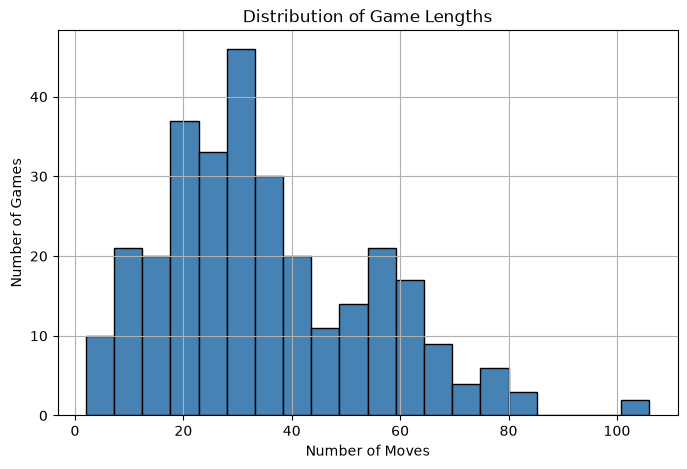

In [62]:
game_lengths = (
    df_moves.groupby("game_id")["move_number"]
    .max()
)
plt.figure(figsize=(8,5))

game_lengths.hist(bins=20, color="steelblue", edgecolor="black")

plt.title("Distribution of Game Lengths")
plt.xlabel("Number of Moves")
plt.ylabel("Number of Games")
plt.show()

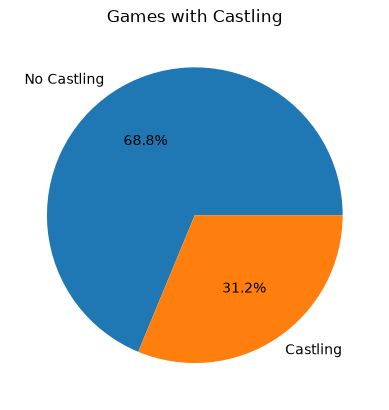

In [67]:
castling_games = (
    df_moves.groupby("game_id")["is_castling"]
    .any()
)
castling_games.value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["No Castling", "Castling"]
)

plt.title("Games with Castling")
plt.ylabel("")
plt.show()

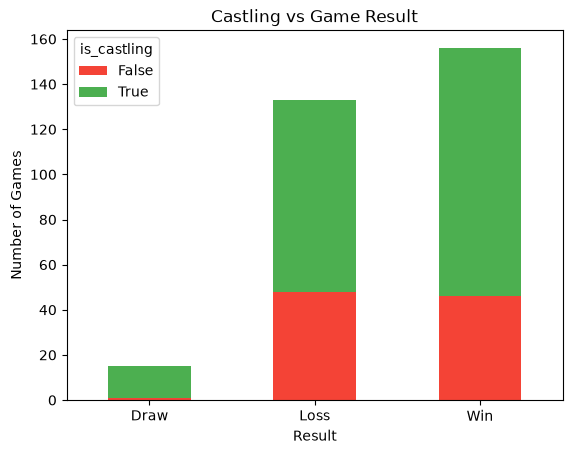

In [68]:
game_castle = df_moves.groupby("game_id")["is_castling"].any()

df_castle = df_games.merge(
    game_castle,
    on="game_id"
)

df_castle.groupby(["result", "is_castling"]).size().unstack().plot(
    kind="bar",
    stacked=True,
    color=["#F44336", "#4CAF50"]
)

plt.title("Castling vs Game Result")
plt.xlabel("Result")
plt.ylabel("Number of Games")
plt.xticks(rotation=0)
plt.show()

Text(0.5, 1.0, 'Average Remaining Time')

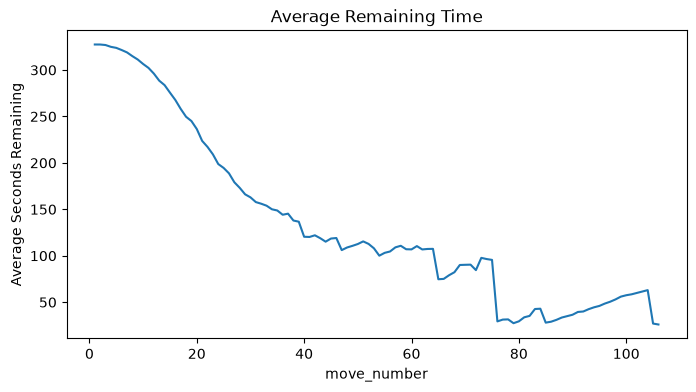

In [58]:
df_moves.groupby("move_number")["clock"].mean().plot(figsize=(8,4))

plt.ylabel("Average Seconds Remaining")
plt.title("Average Remaining Time")

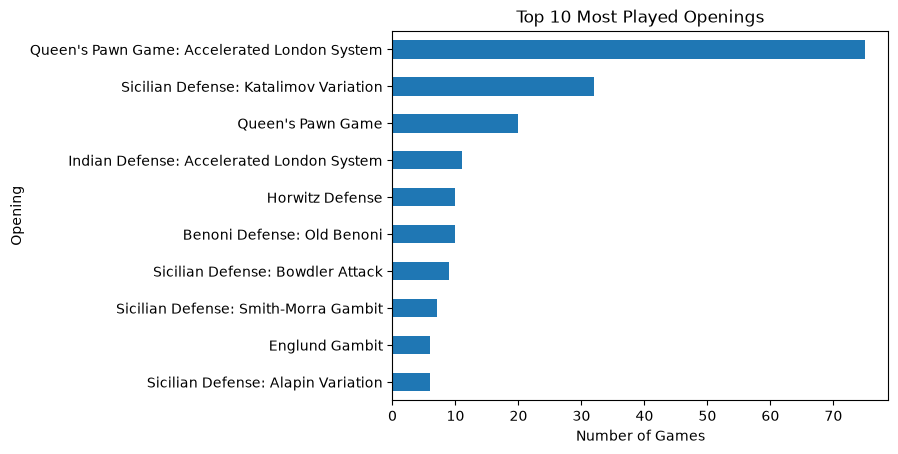

In [70]:
df_moves.groupby("opening")["game_id"].nunique() \
    .sort_values(ascending=False).head(10) \
    .plot(kind="barh")

plt.title("Top 10 Most Played Openings")
plt.xlabel("Number of Games")
plt.ylabel("Opening")
plt.gca().invert_yaxis()  # optional: makes top opening appear at top

In [73]:
df_game_opening = df_moves.groupby("game_id").agg({
    "opening": "first",
    "result": "first"
}).reset_index()

In [74]:
top_openings = df_game_opening["opening"].value_counts().head(10).index

In [75]:
df_top = df_game_opening[df_game_opening["opening"].isin(top_openings)]

summary = pd.crosstab(df_top["opening"], df_top["result"])

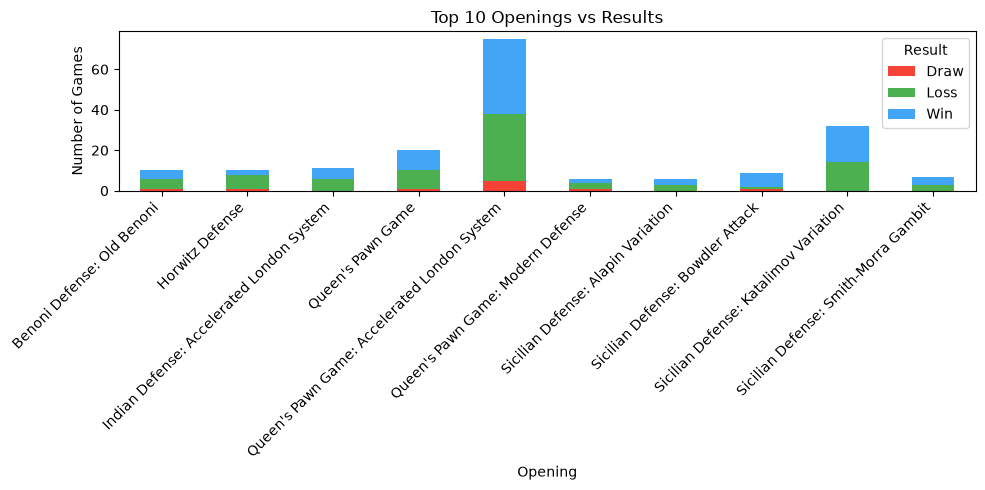

In [76]:
summary.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    color=["#F44336", "#4CAF50", "#42A5F5"]
)

plt.title("Top 10 Openings vs Results")
plt.xlabel("Opening")
plt.ylabel("Number of Games")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Result")
plt.tight_layout()
plt.show()

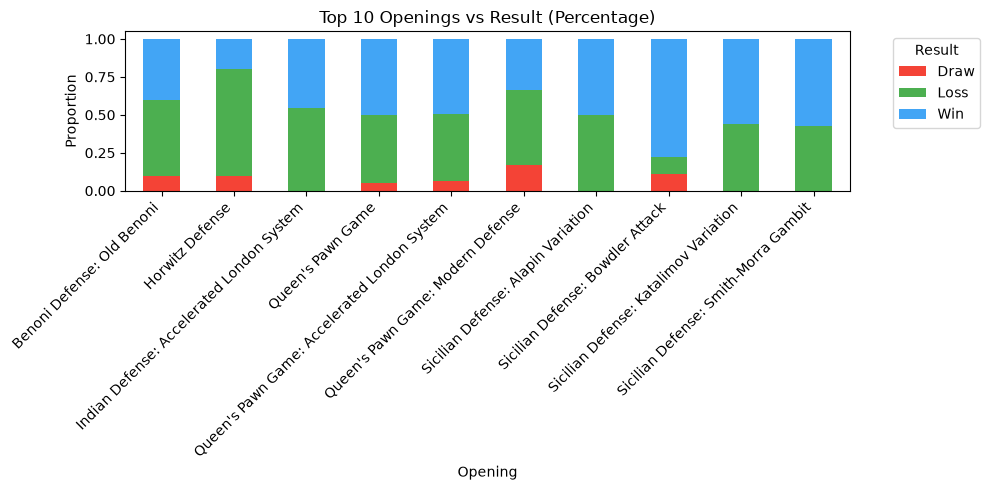

In [77]:
summary_pct = summary.div(summary.sum(axis=1), axis=0)

summary_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    color=["#F44336", "#4CAF50", "#42A5F5"]
)

plt.title("Top 10 Openings vs Result (Percentage)")
plt.xlabel("Opening")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Result", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()